# Class 09 — Why Most Research Findings Are False
**DSC 215 · Statistical Critical Thinking & Experimental Design · UCSD**

*Based on Ioannidis (2005), PLOS Medicine*

---

The central argument: p-values answer **P(data | H₀ is true)** — the probability of the observed result if there is no effect. But what researchers and readers actually care about is **P(true effect | significant result)** — the probability the finding is real. These are very different quantities, and confusing them is why most published findings may be false.

**Contents:**
1. [Setup & Imports](#1)
2. [PPV — The Medical Diagnosis Analogy](#2)
3. [The Research PPV Formula](#3)
4. [Effect of Prior f and Power γ on PPV](#4)
5. [Publication Bias — The u Parameter](#5)
6. [The Multiple-Teams Paradox](#6)
7. [PPV and the False Discovery Rate (FDR)](#7)
8. [Simulating the Replication Crisis](#8)
9. [Summary & Corollaries](#9)

---

<a id='1'></a>
## 1. Setup & Imports

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import cm
import seaborn as sns
from scipy import stats

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

BLUE   = '#2563EB'
RED    = '#DC2626'
GREEN  = '#16A34A'
ORANGE = '#D97706'
GRAY   = '#6B7280'
PURPLE = '#7C3AED'

print('Ready.')

Ready.


<a id='2'></a>
## 2. PPV — The Medical Diagnosis Analogy

The slides open with lung cancer screening. This is not a digression — it is the exact same mathematical structure as the research problem.

**Bayes' rule applied to a diagnostic test:**

$$\text{PPV} = P(\text{disease} \mid +) = \frac{P(+ \mid \text{disease}) \cdot P(\text{disease})}{P(+)}$$

$$= \frac{\text{Sensitivity} \times \text{Prevalence}}{\text{Sensitivity} \times \text{Prevalence} + (1 - \text{Specificity}) \times (1 - \text{Prevalence})}$$

In [10]:
def ppv_medical(sensitivity, specificity, prevalence):
    """Positive Predictive Value from a diagnostic test."""
    tp_rate = sensitivity * prevalence
    fp_rate = (1 - specificity) * (1 - prevalence)
    return tp_rate / (tp_rate + fp_rate)

# Lung cancer screening from the slides
sens        = 0.94
spec        = 0.73
prevalence  = 0.01

ppv = ppv_medical(sens, spec, prevalence)
print(f'Lung cancer screening PPV: {ppv:.1%}')
print(f'Despite 94% sensitivity, a positive test only means {ppv:.1%} probability of cancer.')
print(f'This is entirely driven by the low prevalence of {prevalence:.0%}.')

Lung cancer screening PPV: 3.4%
Despite 94% sensitivity, a positive test only means 3.4% probability of cancer.
This is entirely driven by the low prevalence of 1%.


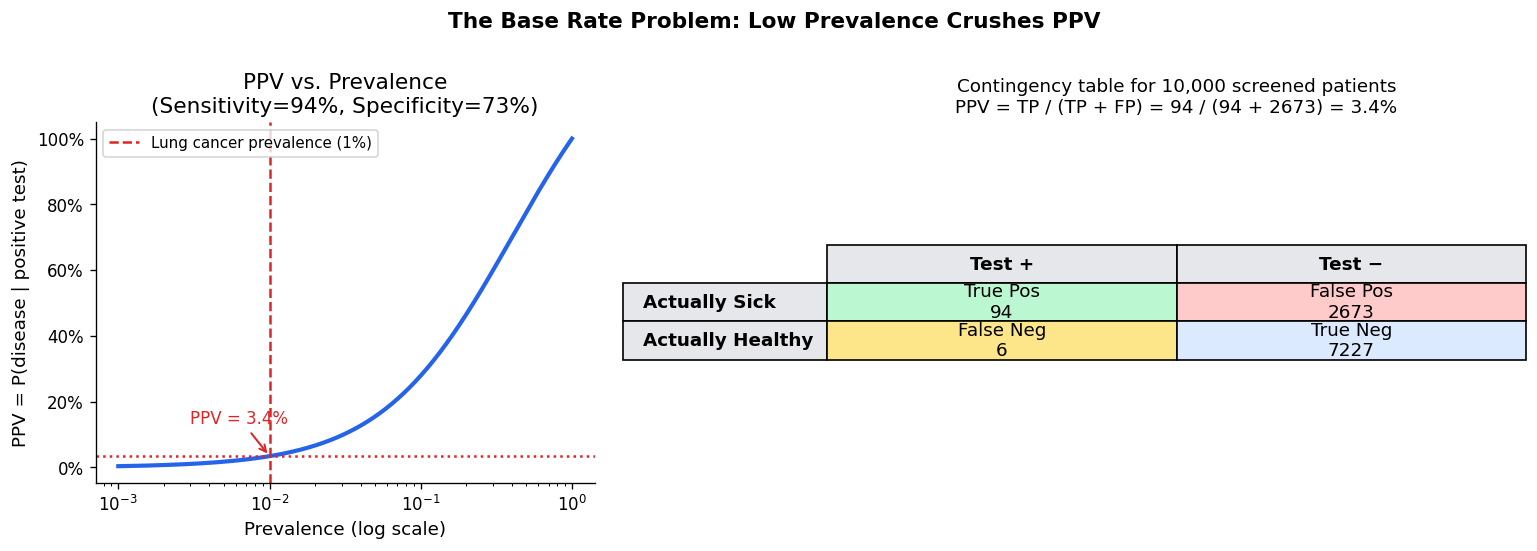

✓ Saved: figures/01_ppv_medical.png


In [11]:
# How PPV changes across a wide range of prevalences
prevalences = np.logspace(-3, 0, 300)  # 0.1% to 100%

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: fixed sens/spec, vary prevalence
ax = axes[0]
ppv_vals = [ppv_medical(sens, spec, p) for p in prevalences]
ax.semilogx(prevalences, ppv_vals, color=BLUE, lw=2.5)
ax.axvline(0.01, color=RED, ls='--', lw=1.5, label='Lung cancer prevalence (1%)')
ax.axhline(ppv,  color=RED, ls=':',  lw=1.5)
ax.annotate(f'PPV = {ppv:.1%}', xy=(0.01, ppv), xytext=(0.003, ppv + 0.1),
            fontsize=10, color=RED,
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))
ax.set_xlabel('Prevalence (log scale)')
ax.set_ylabel('PPV = P(disease | positive test)')
ax.set_title(f'PPV vs. Prevalence\n(Sensitivity={sens:.0%}, Specificity={spec:.0%})')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Right: contingency table for intuition — 10,000 screened
ax2 = axes[1]
N = 10000
n_sick    = int(N * prevalence)
n_healthy = N - n_sick
tp = int(n_sick    * sens)
fn = n_sick    - tp
fp = int(n_healthy * (1 - spec))
tn = n_healthy - fp

data = np.array([[tp, fp], [fn, tn]])
labels = [[f'True Pos\n{tp}', f'False Pos\n{fp}'],
          [f'False Neg\n{fn}', f'True Neg\n{tn}']]
colors = [['#bbf7d0', '#fecaca'], ['#fde68a', '#dbeafe']]

ax2.axis('off')
table = ax2.table(
    cellText=labels,
    rowLabels=['Actually Sick', 'Actually Healthy'],
    colLabels=['Test +', 'Test −'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 2.2)
for (r, c), cell in table.get_celld().items():
    if r == 0 or c == -1:
        cell.set_facecolor('#e5e7eb')
        cell.set_text_props(fontweight='bold')
    elif r > 0 and c >= 0:
        cell.set_facecolor(colors[r-1][c])

ax2.set_title(f'Contingency table for {N:,} screened patients\n'
              f'PPV = TP / (TP + FP) = {tp} / ({tp} + {fp}) = {tp/(tp+fp):.1%}',
              fontsize=11)

plt.suptitle('The Base Rate Problem: Low Prevalence Crushes PPV', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/01_ppv_medical.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/01_ppv_medical.png')

<a id='3'></a>
## 3. The Research PPV Formula

The mapping from medicine to research is exact:

| Medical | Research |
|---------|----------|
| Sensitivity P(+ \| disease) | Power $\gamma = 1 - \beta$ |
| False positive rate P(+ \| healthy) | Significance level $\alpha$ |
| Prevalence P(disease) | Prior prob. of a true effect $f$ |
| PPV | P(true effect \| significant result) |

$$\text{PPV} = \frac{\gamma f}{\gamma f + \alpha(1-f)} = \frac{(1-\beta)R}{(1-\beta)R + \alpha}$$

where $R = f/(1-f)$ is the pre-study odds of a true effect.

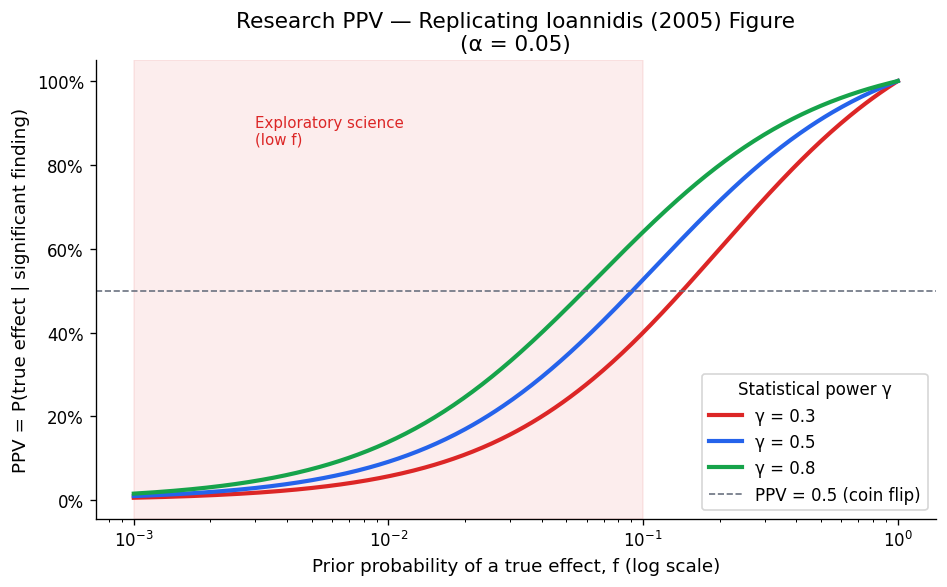

✓ Saved: figures/02_ppv_research.png

=== Numeric examples (α=0.05) ===
  f=0.5 (confirmatory), γ=0.3: PPV=85.7%
  f=0.5 (confirmatory), γ=0.8: PPV=94.1%
  f=0.1, γ=0.3: PPV=40.0%
  f=0.1, γ=0.8: PPV=64.0%
  f=0.01 (exploratory), γ=0.3: PPV=5.7%
  f=0.01 (exploratory), γ=0.8: PPV=13.9%
  f=0.001 (fishing), γ=0.3: PPV=0.6%
  f=0.001 (fishing), γ=0.8: PPV=1.6%


In [12]:
def ppv_research(f, gamma, alpha=0.05):
    """PPV for a research finding. Eq. from Ioannidis (2005).
    f     : prior probability of a true effect
    gamma : statistical power (1 - beta)
    alpha : significance threshold
    """
    return (gamma * f) / (gamma * f + alpha * (1 - f))

def ppv_research_R(R, gamma, alpha=0.05):
    """PPV using pre-study odds R instead of f."""
    return ((1 - (1-gamma)) * R) / ((1 - (1-gamma)) * R + alpha)

# Reproduce the slide: alpha=0.05, vary f and gamma
f_vals     = np.logspace(-3, 0, 400)
gammas     = [0.3, 0.5, 0.8]
colors_g   = [RED, BLUE, GREEN]

fig, ax = plt.subplots(figsize=(8, 5))
for gamma, col in zip(gammas, colors_g):
    ppv_vals = [ppv_research(f, gamma) for f in f_vals]
    ax.semilogx(f_vals, ppv_vals, color=col, lw=2.5, label=f'γ = {gamma}')

# Mark the 50% PPV threshold
ax.axhline(0.5, color=GRAY, ls='--', lw=1, label='PPV = 0.5 (coin flip)')
ax.set_xlabel('Prior probability of a true effect, f (log scale)')
ax.set_ylabel('PPV = P(true effect | significant finding)')
ax.set_title('Research PPV — Replicating Ioannidis (2005) Figure\n(α = 0.05)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(title='Statistical power γ')

# Annotate the "most findings are false" region
ax.axvspan(1e-3, 0.1, alpha=0.08, color=RED)
ax.text(0.003, 0.85, 'Exploratory science\n(low f)', color=RED, fontsize=9)

plt.tight_layout()
plt.savefig('figures/02_ppv_research.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/02_ppv_research.png')

# Numeric examples from the slides
print('\n=== Numeric examples (α=0.05) ===')
for f_ex, label in [(0.5, 'f=0.5 (confirmatory)'), (0.1, 'f=0.1'), (0.01, 'f=0.01 (exploratory)'), (0.001, 'f=0.001 (fishing)')]:
    for g in [0.3, 0.8]:
        print(f'  {label}, γ={g}: PPV={ppv_research(f_ex, g):.1%}')

<a id='4'></a>
## 4. Effect of Prior f and Power γ — Full Surface

Below we plot the PPV as a 2D heatmap over the full (f, γ) space. This makes the joint effect visually immediate.

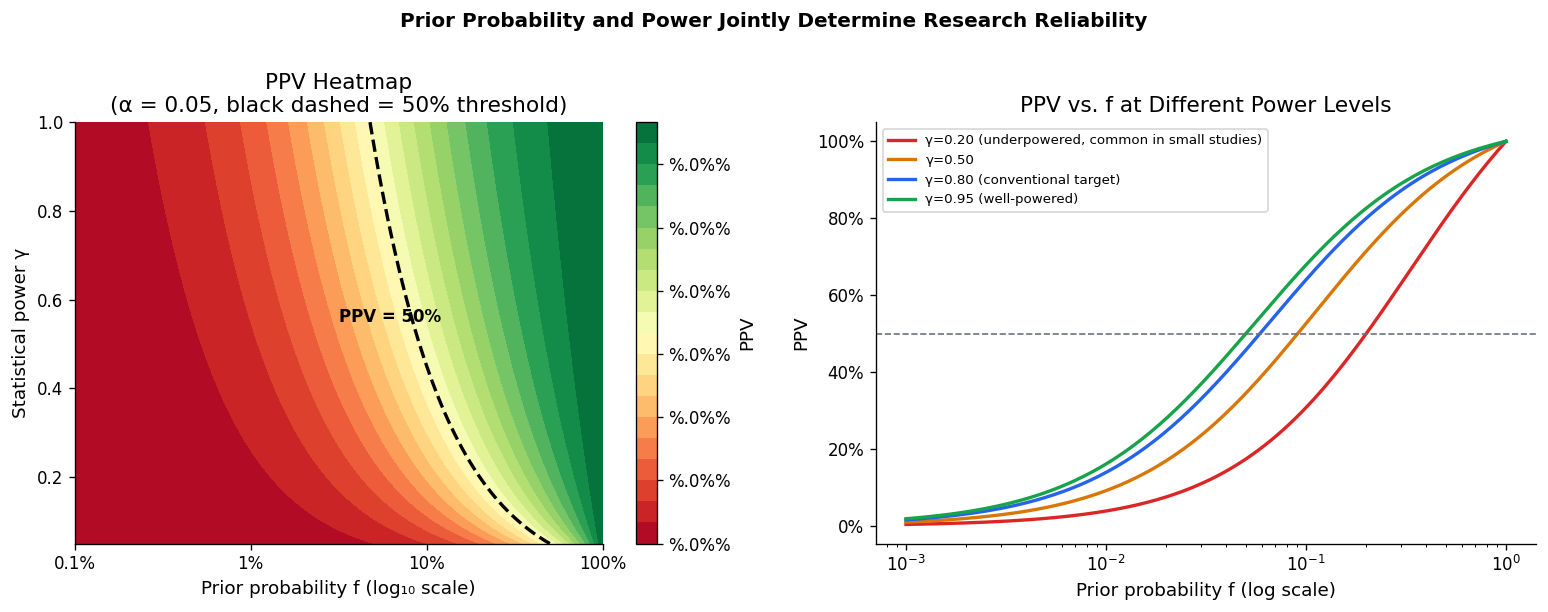

✓ Saved: figures/03_ppv_surface.png


In [13]:
f_grid     = np.logspace(-3, 0, 200)
gamma_grid = np.linspace(0.05, 1.0, 200)
F, G       = np.meshgrid(f_grid, gamma_grid)
PPV_grid   = ppv_research(F, G, alpha=0.05)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap
ax = axes[0]
im = ax.contourf(np.log10(f_grid), gamma_grid, PPV_grid,
                 levels=20, cmap='RdYlGn', vmin=0, vmax=1)
ax.contour(np.log10(f_grid), gamma_grid, PPV_grid,
           levels=[0.5], colors='black', linewidths=2, linestyles='--')
ax.text(-1.5, 0.55, 'PPV = 50%', color='black', fontsize=10, fontweight='bold')
ax.set_xlabel('Prior probability f (log₁₀ scale)')
ax.set_ylabel('Statistical power γ')
ax.set_title('PPV Heatmap\n(α = 0.05, black dashed = 50% threshold)')
ax.set_xticks([-3, -2, -1, 0])
ax.set_xticklabels(['0.1%', '1%', '10%', '100%'])
plt.colorbar(im, ax=ax, label='PPV', format='%.0%%')

# Cross-sections at fixed realistic power levels
ax2 = axes[1]
for gamma, col, label in [
    (0.2,  RED,    'γ=0.20 (underpowered, common in small studies)'),
    (0.5,  ORANGE, 'γ=0.50'),
    (0.8,  BLUE,   'γ=0.80 (conventional target)'),
    (0.95, GREEN,  'γ=0.95 (well-powered)'),
]:
    ax2.semilogx(f_grid, [ppv_research(f, gamma) for f in f_grid],
                 color=col, lw=2, label=label)

ax2.axhline(0.5, color=GRAY, ls='--', lw=1)
ax2.set_xlabel('Prior probability f (log scale)')
ax2.set_ylabel('PPV')
ax2.set_title('PPV vs. f at Different Power Levels')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend(fontsize=8)

plt.suptitle('Prior Probability and Power Jointly Determine Research Reliability',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/03_ppv_surface.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/03_ppv_surface.png')

<a id='5'></a>
## 5. Publication Bias — The u Parameter

Ioannidis introduces $u$ as the proportion of non-significant analyses that still get reported as significant (p-hacking, selective reporting, HARKing — Hypothesizing After Results are Known).

$$P(\text{finding} \mid \text{no effect}) = \alpha + u(1-\alpha)$$
$$P(\text{finding} \mid \text{effect})    = \gamma + u(1-\gamma)$$

$$\text{PPV}_{\text{biased}} = \frac{(1-\beta+u\beta)R}{(1-\beta+u\beta)R + \alpha + u(1-\alpha)}$$

**What $u$ represents in practice:**
- $u = 0$: honest reporting
- $u = 0.2$: mild p-hacking (trying a few alternative analyses until p < 0.05)
- $u = 0.5$: substantial bias (publish positive, file-drawer negative)
- $u = 1.0$: everything reported as significant regardless of truth

C:\Users\aldai\AppData\Local\Temp\ipykernel_17296\1342415628.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  R = f / (1 - f)
C:\Users\aldai\AppData\Local\Temp\ipykernel_17296\1342415628.py:7: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator


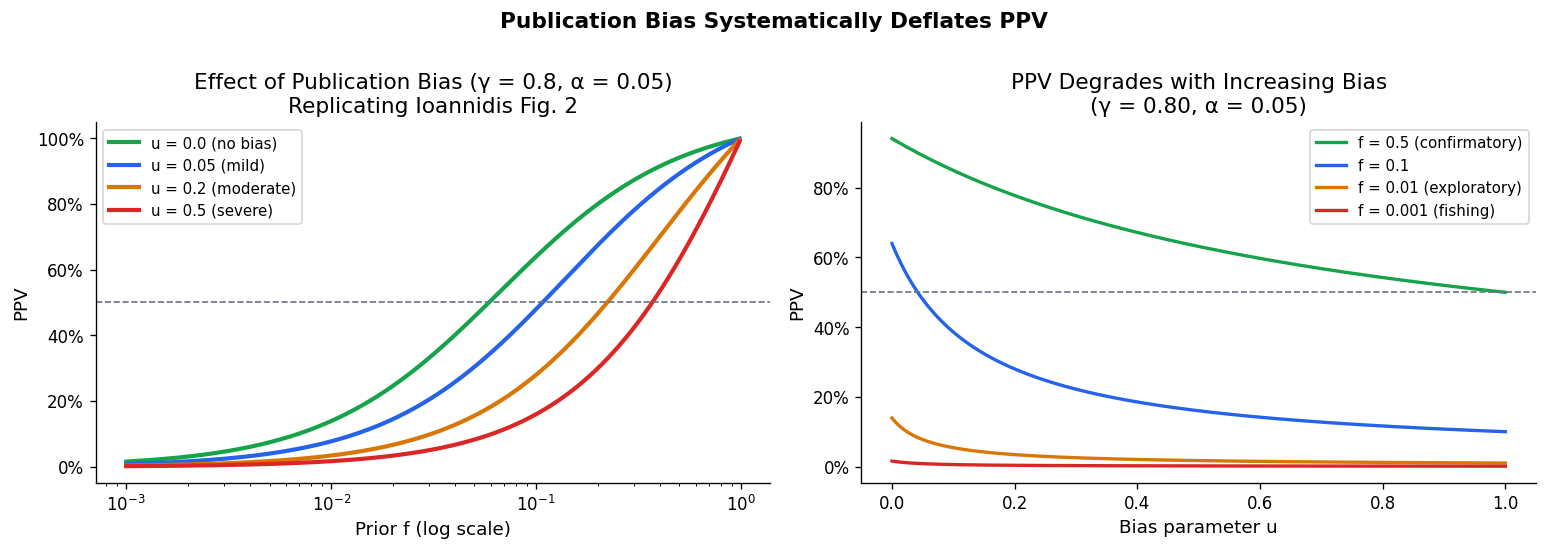

✓ Saved: figures/04_publication_bias.png


In [14]:
def ppv_biased(f, gamma, alpha=0.05, u=0):
    """PPV with publication bias parameter u."""
    beta = 1 - gamma
    R = f / (1 - f)
    numerator   = (1 - beta + u * beta) * R
    denominator = numerator + alpha + u * (1 - alpha)
    return numerator / denominator

f_vals = np.logspace(-3, 0, 400)
u_vals = [0.0, 0.05, 0.2, 0.5]
u_colors = [GREEN, BLUE, ORANGE, RED]
gamma_fixed = 0.8

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for u, col in zip(u_vals, u_colors):
    ppv_u = [ppv_biased(f, gamma_fixed, u=u) for f in f_vals]
    ax.semilogx(f_vals, ppv_u, color=col, lw=2.5,
                label=f'u = {u} ({"no bias" if u==0 else "mild" if u<=0.05 else "moderate" if u<=0.2 else "severe"})')
ax.axhline(0.5, color=GRAY, ls='--', lw=1)
ax.set_xlabel('Prior f (log scale)')
ax.set_ylabel('PPV')
ax.set_title(f'Effect of Publication Bias (γ = {gamma_fixed}, α = 0.05)\nReplicating Ioannidis Fig. 2')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=9)

# Right: how much bias costs at different f values
ax2 = axes[1]
u_range = np.linspace(0, 1, 200)
for f_ex, col, label in [
    (0.5,  GREEN,  'f = 0.5 (confirmatory)'),
    (0.1,  BLUE,   'f = 0.1'),
    (0.01, ORANGE, 'f = 0.01 (exploratory)'),
    (0.001, RED,   'f = 0.001 (fishing)'),
]:
    ax2.plot(u_range, [ppv_biased(f_ex, gamma_fixed, u=u) for u in u_range],
             color=col, lw=2, label=label)
ax2.axhline(0.5, color=GRAY, ls='--', lw=1)
ax2.set_xlabel('Bias parameter u')
ax2.set_ylabel('PPV')
ax2.set_title('PPV Degrades with Increasing Bias\n(γ = 0.80, α = 0.05)')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend(fontsize=9)

plt.suptitle('Publication Bias Systematically Deflates PPV', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/04_publication_bias.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/04_publication_bias.png')

<a id='6'></a>
## 6. The Multiple-Teams Paradox

Intuitively, more labs testing the same thing should increase reliability. The math says otherwise.

With $n$ independent teams:
- Type-I error = $1 - (1-\alpha)^n$ — grows quickly: with 10 teams at $\alpha=0.05$, there's a 40% chance of at least one false positive even if there's no real effect
- Type-II error = $\beta^n$ — shrinks quickly

The key asymmetry: the team that finds the effect publishes prominently; the teams that don't replicate often don't publish at all. This **selective publication** means that as $n$ grows, the false positive rate that matters in practice grows with it.

C:\Users\aldai\AppData\Local\Temp\ipykernel_17296\1797052906.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  R = f / (1 - f)
C:\Users\aldai\AppData\Local\Temp\ipykernel_17296\1797052906.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return (power_n * R) / (power_n * R + type1_n)


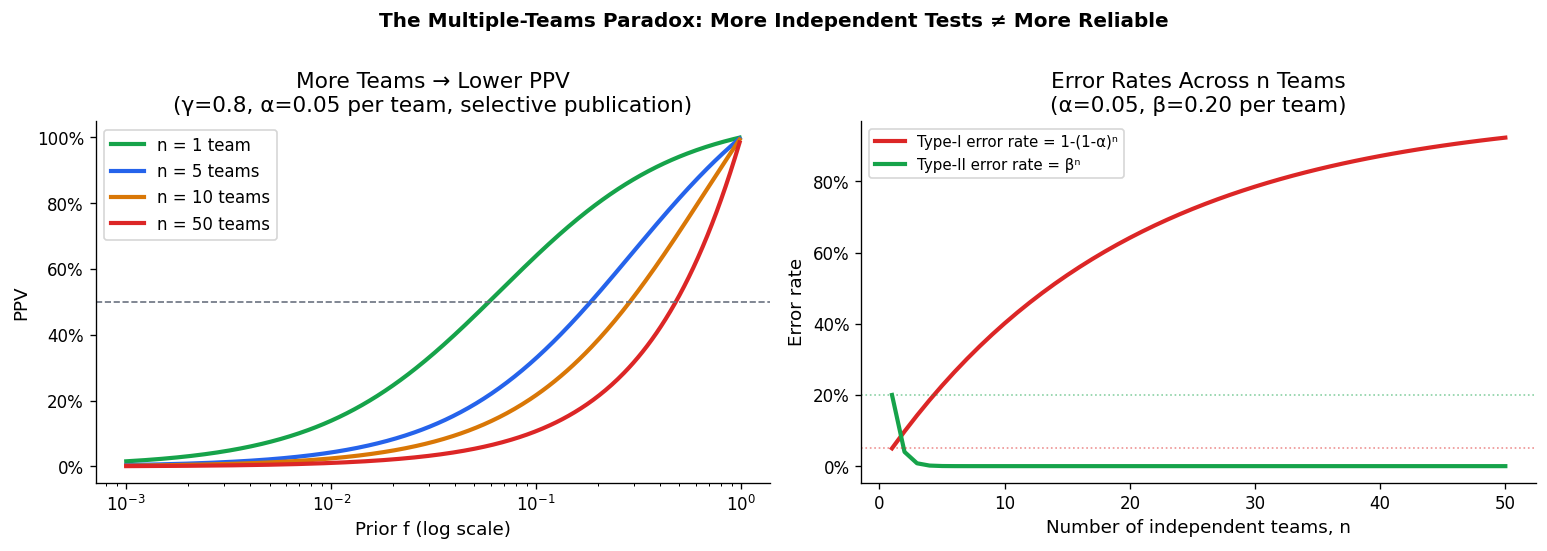

✓ Saved: figures/05_multiple_teams.png


In [15]:
def ppv_multiple_teams(f, n, gamma=0.8, alpha=0.05):
    """PPV when n independent teams test the same hypothesis."""
    beta = 1 - gamma
    R = f / (1 - f)
    type1_n = 1 - (1 - alpha) ** n
    type2_n = beta ** n
    power_n = 1 - type2_n
    return (power_n * R) / (power_n * R + type1_n)

f_vals = np.logspace(-3, 0, 400)
n_teams_list = [1, 5, 10, 50]
n_colors = [GREEN, BLUE, ORANGE, RED]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for n, col in zip(n_teams_list, n_colors):
    ppv_n = [ppv_multiple_teams(f, n) for f in f_vals]
    ax.semilogx(f_vals, ppv_n, color=col, lw=2.5, label=f'n = {n} team{"s" if n>1 else ""}')
ax.axhline(0.5, color=GRAY, ls='--', lw=1)
ax.set_xlabel('Prior f (log scale)')
ax.set_ylabel('PPV')
ax.set_title('More Teams → Lower PPV\n(γ=0.8, α=0.05 per team, selective publication)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()

# Right: growing Type-I error with n
ax2 = axes[1]
n_range = np.arange(1, 51)
type1_n = 1 - (1 - 0.05) ** n_range
type2_n = 0.2 ** n_range  # beta = 0.2
ax2.plot(n_range, type1_n, color=RED,   lw=2.5, label='Type-I error rate = 1-(1-α)ⁿ')
ax2.plot(n_range, type2_n, color=GREEN, lw=2.5, label='Type-II error rate = βⁿ')
ax2.axhline(0.05, color=RED,   ls=':', lw=1, alpha=0.5)
ax2.axhline(0.2,  color=GREEN, ls=':', lw=1, alpha=0.5)
ax2.set_xlabel('Number of independent teams, n')
ax2.set_ylabel('Error rate')
ax2.set_title('Error Rates Across n Teams\n(α=0.05, β=0.20 per team)')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend(fontsize=9)

plt.suptitle('The Multiple-Teams Paradox: More Independent Tests ≠ More Reliable',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/05_multiple_teams.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/05_multiple_teams.png')

<a id='7'></a>
## 7. PPV and the False Discovery Rate (FDR)

The **False Discovery Rate** is the complement of PPV:

$$\text{FDR} = 1 - \text{PPV} = P(\text{no true effect} \mid \text{significant result})$$

Ioannidis claims FDR > 50% for most published findings. Jager & Leek (2014) empirically estimated FDR ≈ 14% using actual p-value distributions from medical journals — a substantial disagreement driven by different assumptions about $f$, $\gamma$, and $u$.

=== PPV and FDR under different scenarios ===
                                                      PPV    FDR
Ioannidis: Exploratory field\n(f=0.1, γ=0.5, u=...  21.7%  78.3%
Ioannidis: Hot field\n(f=0.1, γ=0.5, u=0.5)         13.7%  86.3%
Confirmatory, no bias\n(f=0.5, γ=0.8, u=0.0)        94.1%   5.9%
Jager & Leek estimate\n(f=0.3, γ=0.8, u=0.05)       78.1%  21.9%
Underpowered, small sample\n(f=0.1, γ=0.2, u=0.1)   17.7%  82.3%


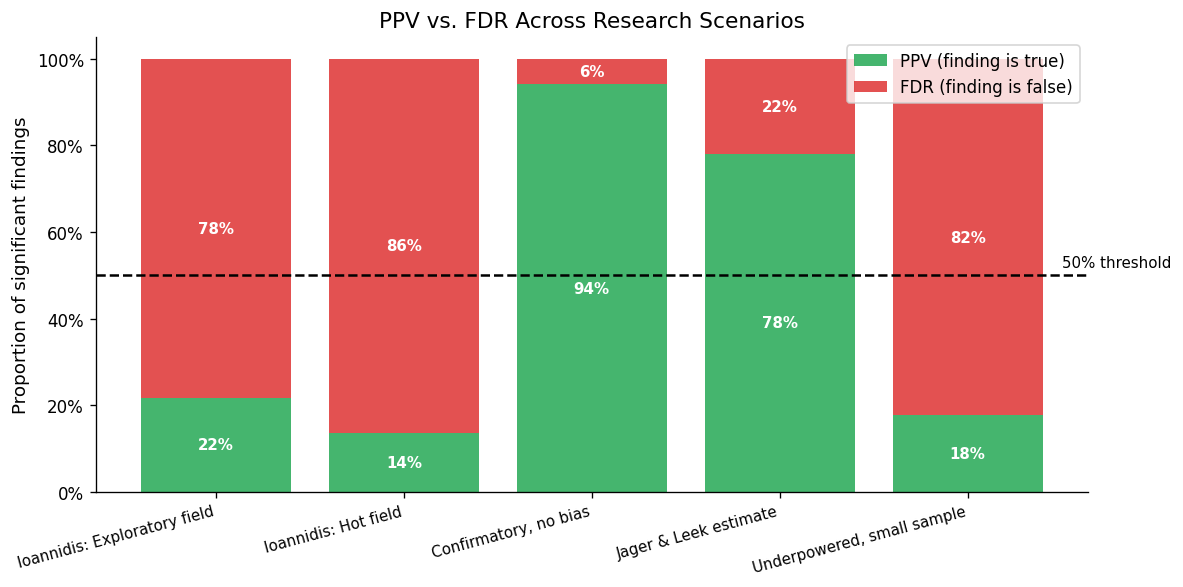

✓ Saved: figures/06_ppv_fdr_scenarios.png


In [16]:
# Compare Ioannidis' assumed parameters vs. Jager & Leek's empirical estimate
scenarios = {
    'Ioannidis: Exploratory field\n(f=0.1, γ=0.5, u=0.2)':  {'f': 0.10, 'gamma': 0.50, 'u': 0.20},
    'Ioannidis: Hot field\n(f=0.1, γ=0.5, u=0.5)':          {'f': 0.10, 'gamma': 0.50, 'u': 0.50},
    'Confirmatory, no bias\n(f=0.5, γ=0.8, u=0.0)':         {'f': 0.50, 'gamma': 0.80, 'u': 0.00},
    'Jager & Leek estimate\n(f=0.3, γ=0.8, u=0.05)':        {'f': 0.30, 'gamma': 0.80, 'u': 0.05},
    'Underpowered, small sample\n(f=0.1, γ=0.2, u=0.1)':    {'f': 0.10, 'gamma': 0.20, 'u': 0.10},
}

ppv_results = {}
for name, params in scenarios.items():
    ppv_val = ppv_biased(params['f'], params['gamma'], u=params['u'])
    fdr_val = 1 - ppv_val
    ppv_results[name] = {'PPV': ppv_val, 'FDR': fdr_val}

results_df = pd.DataFrame(ppv_results).T
print('=== PPV and FDR under different scenarios ===')
print(results_df.map(lambda x: f'{x:.1%}'))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(scenarios))
short_labels = [s.split('\n')[0] for s in scenarios.keys()]
ppv_bar = [ppv_results[s]['PPV'] for s in scenarios]
fdr_bar = [ppv_results[s]['FDR'] for s in scenarios]

ax.bar(x, ppv_bar, color=GREEN, alpha=0.8, label='PPV (finding is true)')
ax.bar(x, fdr_bar, bottom=ppv_bar, color=RED, alpha=0.8, label='FDR (finding is false)')
ax.axhline(0.5, color='black', ls='--', lw=1.5)
ax.text(len(scenarios)-0.5, 0.52, '50% threshold', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Proportion of significant findings')
ax.set_title('PPV vs. FDR Across Research Scenarios')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()

for i, (ppv_v, fdr_v) in enumerate(zip(ppv_bar, fdr_bar)):
    ax.text(i, ppv_v/2,      f'{ppv_v:.0%}', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    ax.text(i, ppv_v + fdr_v/2, f'{fdr_v:.0%}', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/06_ppv_fdr_scenarios.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/06_ppv_fdr_scenarios.png')

<a id='8'></a>
## 8. Simulating the Replication Crisis

We simulate a research literature: many labs each test hypotheses, some true and some false. We observe what happens to the mix of published findings under different bias levels.

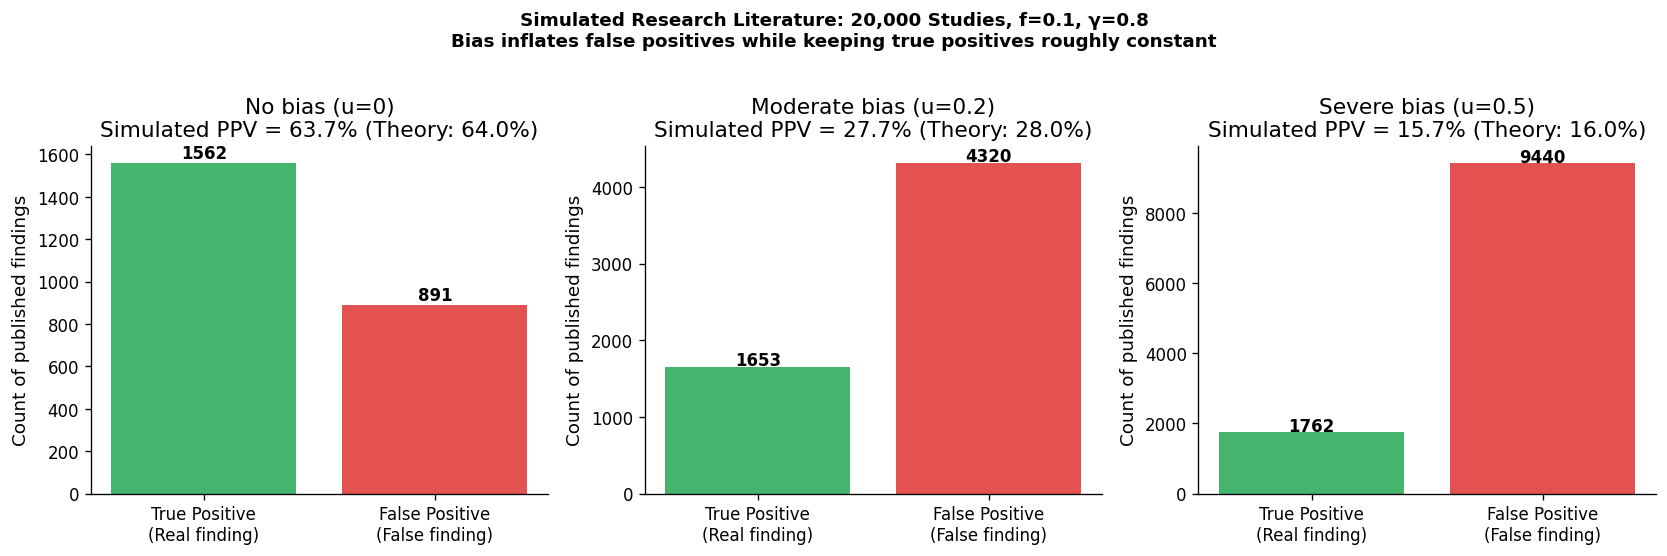

✓ Saved: figures/07_simulation.png


In [17]:
def simulate_research_literature(n_studies=10000, f=0.1, gamma=0.8,
                                  alpha=0.05, u=0.0, seed=42):
    """
    Simulate a research literature.
    Returns a DataFrame with columns: true_effect, finding, true_positive.
    """
    rng = np.random.default_rng(seed)
    true_effect = rng.random(n_studies) < f

    # Unbiased finding probability
    p_finding = np.where(true_effect,
                         gamma + u * (1 - gamma),
                         alpha + u * (1 - alpha))
    finding = rng.random(n_studies) < p_finding

    return pd.DataFrame({
        'true_effect': true_effect,
        'finding':     finding,
        'true_positive': true_effect & finding,
        'false_positive': (~true_effect) & finding,
    })

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
bias_scenarios = [
    (0.0,  'No bias (u=0)',   GREEN),
    (0.2,  'Moderate bias (u=0.2)', ORANGE),
    (0.5,  'Severe bias (u=0.5)',   RED),
]

for ax, (u, title, col) in zip(axes, bias_scenarios):
    df = simulate_research_literature(n_studies=20000, f=0.1, gamma=0.8, alpha=0.05, u=u)
    published = df[df['finding']]
    tp_count = published['true_positive'].sum()
    fp_count = published['false_positive'].sum()
    ppv_sim  = tp_count / (tp_count + fp_count)
    ppv_theo = ppv_biased(0.1, 0.8, u=u)

    ax.bar(['True Positive\n(Real finding)', 'False Positive\n(False finding)'],
           [tp_count, fp_count],
           color=[GREEN, RED], alpha=0.8)
    ax.set_title(f'{title}\nSimulated PPV = {ppv_sim:.1%} (Theory: {ppv_theo:.1%})')
    ax.set_ylabel('Count of published findings')
    for i, v in enumerate([tp_count, fp_count]):
        ax.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle('Simulated Research Literature: 20,000 Studies, f=0.1, γ=0.8\n'
             'Bias inflates false positives while keeping true positives roughly constant',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/07_simulation.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/07_simulation.png')

<a id='9'></a>
## 9. Summary & Corollaries

All six of Ioannidis' corollaries follow directly from the PPV formula:

In [18]:
corollaries = pd.DataFrame([
    {
        '#': 1,
        'Condition': 'Small sample size',
        'Mechanism': 'Reduces power γ',
        'PPV effect': '↓',
        'Real-world example': 'Most early-phase clinical trials, n < 50'
    },
    {
        '#': 2,
        'Condition': 'Small true effect size',
        'Mechanism': 'Reduces power γ',
        'PPV effect': '↓',
        'Real-world example': 'Candidate gene studies; most SNPs have tiny OR'
    },
    {
        '#': 3,
        'Condition': 'Many tested hypotheses, poor design',
        'Mechanism': 'Reduces prior f',
        'PPV effect': '↓',
        'Real-world example': 'GWAS without biological priors; exploratory fMRI'
    },
    {
        '#': 4,
        'Condition': 'Non-rigorous analysis (p-hacking)',
        'Mechanism': 'Increases bias u',
        'PPV effect': '↓',
        'Real-world example': 'Selective outcome reporting, stopping early'
    },
    {
        '#': 5,
        'Condition': 'Financial conflicts of interest',
        'Mechanism': 'Increases bias u',
        'PPV effect': '↓',
        'Real-world example': 'Pharma-funded trials vs. independent replications'
    },
    {
        '#': 6,
        'Condition': 'Hot or exploratory field',
        'Mechanism': 'Low f AND high u',
        'PPV effect': '↓↓',
        'Real-world example': 'Early COVID-19 drug repurposing studies (2020)'
    },
])

pd.set_option('display.max_colwidth', 55)
corollaries.set_index('#')

,Condition,Mechanism,PPV effect,Real-world example
#,,,,
1,Small sample size,Reduces power γ,↓,"Most early-phase clinical trials, n < 50"
2,Small true effect size,Reduces power γ,↓,Candidate gene studies; most SNPs have tiny OR
3,"Many tested hypotheses, poor design",Reduces prior f,↓,GWAS without biological priors; exploratory fMRI
4,Non-rigorous analysis (p-hacking),Increases bias u,↓,"Selective outcome reporting, stopping early"
5,Financial conflicts of interest,Increases bias u,↓,Pharma-funded trials vs. independent replications
6,Hot or exploratory field,Low f AND high u,↓↓,Early COVID-19 drug repurposing studies (2020)


In [19]:
# Quantify each corollary numerically
baseline = ppv_research(f=0.3, gamma=0.8)
print(f'Baseline PPV (f=0.3, γ=0.8, α=0.05, u=0): {baseline:.1%}')
print()

comparisons = [
    ('Small sample → low power',    ppv_research(0.3, 0.3)),
    ('Small effect → low power',    ppv_research(0.3, 0.3)),
    ('Exploratory field (low f)',   ppv_research(0.05, 0.8)),
    ('Mild p-hacking (u=0.2)',      ppv_biased(0.3, 0.8, u=0.2)),
    ('Severe bias (u=0.5)',         ppv_biased(0.3, 0.8, u=0.5)),
    ('Hot field (low f + high u)',  ppv_biased(0.05, 0.5, u=0.3)),
]

for label, ppv_val in comparisons:
    delta = ppv_val - baseline
    print(f'  {label:<40}: PPV = {ppv_val:.1%}  ({delta:+.1%} vs baseline)')

Baseline PPV (f=0.3, γ=0.8, α=0.05, u=0): 87.3%

  Small sample → low power                : PPV = 72.0%  (-15.3% vs baseline)
  Small effect → low power                : PPV = 72.0%  (-15.3% vs baseline)
  Exploratory field (low f)               : PPV = 45.7%  (-41.6% vs baseline)
  Mild p-hacking (u=0.2)                  : PPV = 60.0%  (-27.3% vs baseline)
  Severe bias (u=0.5)                     : PPV = 42.4%  (-44.9% vs baseline)
  Hot field (low f + high u)              : PPV = 9.3%  (-78.0% vs baseline)


---

## 📝 Key Takeaways

| Concept | What to Remember |
|---------|------------------|
| **p-value ≠ PPV** | p-value = P(data\|H₀). PPV = P(H₁\|significant). They are not the same. |
| **Base rate dominates** | Low prior $f$ crushes PPV even with a great test — identical to medical screening |
| **Power matters for PPV** | Low power doesn't just miss effects — it poisons the reliability of what gets found |
| **Bias multiplicatively worsens** | p-hacking inflates false positives AND increases denominator of PPV formula |
| **More teams ≠ more reliable** | Selective publication means accumulated Type-I errors with no matching power gain |
| **FDR = 1 − PPV** | Ioannidis: FDR > 50% in many fields. Jager & Leek: ~14% empirically. Both depend on assumed priors. |
| **Fixes** | Pre-registration · larger samples · replication requirements · Bayesian priors |

---

## 📚 References

- Ioannidis, J.P.A. (2005). *Why Most Published Research Findings Are False.* PLOS Medicine 2(8): e124.
- Jager, L.R. & Leek, J.T. (2014). *An estimate of the science-wise false discovery rate and application to the top medical literature.* Biostatistics 15(1): 1–12.
- Gelman, A. & Loken, E. (2014). *The statistical crisis in science.* American Scientist 102(6): 460.

---
*DSC 215 · UCSD · Spring 2026 · Prof. Armin Schwartzman*